# NYC Taxi Trip Duration — Complete Analysis
### Data Analytics & Machine Learning Project
**Steps covered:** Dataset (100k+) → Null Check → Outlier Detection → Cleaning → EDA Visualization → Encoding → Logistic Regression → Evaluation → Benchmark Comparison → Frontend UI

## ─────────────────────────────────────────
## PHASE 1 — Data Loading & Cleaning
## ─────────────────────────────────────────

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', palette='muted')

### Step 1 — Load Dataset (100,000+ entries)

In [3]:
# Load full dataset — original has 100,000+ rows
df = pd.read_csv('NYC.csv')
print(f'Full dataset rows: {len(df):,}')   # confirms 100,000+

# Sample 90,000 rows for computational efficiency
df = df.sample(n=100000, random_state=42).reset_index(drop=True)
print(f'Sampled shape: {df.shape}')        # (90000, 11)

print('\nColumn data types:')
print(df.dtypes)
print('\nFirst 5 rows:')
df.head()

Full dataset rows: 167,743
Sampled shape: (100000, 11)

Column data types:
id                     object
vendor_id               int64
pickup_datetime        object
dropoff_datetime       object
passenger_count       float64
pickup_longitude      float64
pickup_latitude       float64
dropoff_longitude     float64
dropoff_latitude      float64
store_and_fwd_flag     object
trip_duration         float64
dtype: object

First 5 rows:


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id3198989,2,2016-01-30 20:27:02,2016-01-30 20:59:42,1.0,-73.995018,40.722691,-73.980225,40.783737,N,1960.0
1,id0566019,2,2016-03-27 10:28:05,2016-03-27 11:15:17,1.0,-73.974800,40.753262,-73.870567,40.773849,N,2832.0
2,id2619230,2,2016-04-28 14:46:36,2016-04-28 15:02:37,1.0,-73.959488,40.805981,-73.982567,40.772362,N,961.0
3,id0435311,2,2016-01-04 13:54:30,2016-01-04 14:03:14,4.0,-73.989449,40.735832,-73.981064,40.750206,N,524.0
4,id3375835,1,2016-06-15 09:28:54,2016-06-15 09:37:09,1.0,-74.005196,40.725857,-74.010010,40.719955,N,495.0


In [4]:
# Statistical overview before cleaning
print('Statistical summary (before cleaning):')
df.describe()

Statistical summary (before cleaning):


,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.533980,1.664170,-73.973439,40.751032,-73.973381,40.751957,960.740060
std,0.498847,1.311513,0.038555,0.029516,0.036530,0.033492,3262.458452
min,1.000000,0.000000,-75.455917,39.803932,-74.562355,40.441662,2.000000
25%,1.000000,1.000000,-73.991875,40.737335,-73.991280,40.736092,396.000000
50%,2.000000,1.000000,-73.981743,40.754108,-73.979744,40.754559,662.000000
75%,2.000000,2.000000,-73.967239,40.768475,-73.962868,40.769932,1074.000000
max,2.000000,6.000000,-73.424973,43.486885,-72.711395,43.486885,86390.000000


### Step 2 — Check for Null Values

In [5]:
# ── Full null report ──────────────────────────────────────────────────────────
null_counts = df.isnull().sum()
null_pct    = (null_counts / len(df)) * 100
null_report = pd.DataFrame({'Missing Count': null_counts, 'Missing %': null_pct})

print('=== NULL VALUE REPORT ===')
print(null_report.to_string())
print(f'\nTotal missing cells: {null_counts.sum()}')

if null_counts.sum() == 0:
    print('\n Confirmed: No null values found. Dataset is complete.')
else:
    print(f'\n  {null_counts.sum()} missing values detected — applying imputation:')
    # Drop rows missing in critical columns
    df.dropna(subset=['trip_duration', 'pickup_datetime'], inplace=True)

    # Median for numeric columns (robust to outliers)
    for col in df.select_dtypes(include=['float64', 'int64']).columns:
        if df[col].isnull().any():
            med = df[col].median()
            df[col].fillna(med, inplace=True)
            print(f'  Numeric  [{col}]: filled with median = {med:.4f}')

    # Mode for categorical columns
    for col in df.select_dtypes(include=['object']).columns:
        if df[col].isnull().any():
            mod = df[col].mode()[0]
            df[col].fillna(mod, inplace=True)
            print(f'  Categorical [{col}]: filled with mode = {mod}')

    # Final verification
    remaining = df.isnull().sum().sum()
    print(f'\nPost-imputation nulls remaining: {remaining}')

=== NULL VALUE REPORT ===
                    Missing Count  Missing %
id                              0        0.0
vendor_id                       0        0.0
pickup_datetime                 0        0.0
dropoff_datetime                0        0.0
passenger_count                 0        0.0
pickup_longitude                0        0.0
pickup_latitude                 0        0.0
dropoff_longitude               0        0.0
dropoff_latitude                0        0.0
store_and_fwd_flag              0        0.0
trip_duration                   0        0.0

Total missing cells: 0

 Confirmed: No null values found. Dataset is complete.


### Step 3 — Detect Outliers & Wrong Entries (Statistical Methods)

In [6]:
col = 'trip_duration'

# ── Descriptive statistics ────────────────────────────────────────────────────
mean_val   = df[col].mean()
median_val = df[col].median()
mode_val   = df[col].mode()[0]
std_val    = df[col].std()
q1         = df[col].quantile(0.25)
q3         = df[col].quantile(0.75)
iqr        = q3 - q1

print('=== DESCRIPTIVE STATISTICS — trip_duration (BEFORE cleaning) ===')
print(f'  Mean         : {mean_val:>10,.2f} seconds')
print(f'  Median       : {median_val:>10,.2f} seconds')
print(f'  Mode         : {mode_val:>10,.2f} seconds')
print(f'  Std Dev      : {std_val:>10,.2f}')
print(f'  Q1           : {q1:>10,.2f}')
print(f'  Q3           : {q3:>10,.2f}')
print(f'  IQR          : {iqr:>10,.2f}')
print(f'  Min          : {df[col].min():>10,.2f}')
print(f'  Max          : {df[col].max():>10,.2f}')

# ── Method 1 : IQR fences ─────────────────────────────────────────────────────
lower_iqr = q1 - 1.5 * iqr
upper_iqr = q3 + 1.5 * iqr
n_iqr     = ((df[col] < lower_iqr) | (df[col] > upper_iqr)).sum()
print(f'\n[IQR Method]  Lower fence={lower_iqr:,.1f}  Upper fence={upper_iqr:,.1f}  Outliers={n_iqr:,}')

# ── Method 2 : Z-score ────────────────────────────────────────────────────────
z_scores = np.abs(stats.zscore(df[col].dropna()))
n_zscore = (z_scores > 3).sum()
print(f'[Z-Score Method]  |z| > 3  Outliers={n_zscore:,}')

# ── Method 3 : Domain knowledge ───────────────────────────────────────────────
n_below = (df[col] < 60).sum()
n_above = (df[col] > 10800).sum()
print(f'[Domain Filter]  < 60s: {n_below:,}   > 10800s: {n_above:,}')

# ── Wrong entries : passenger_count == 0 ──────────────────────────────────────
n_zero_pax = (df['passenger_count'] == 0).sum()
print(f'[Wrong Entry]    passenger_count == 0: {n_zero_pax:,}')

=== DESCRIPTIVE STATISTICS — trip_duration (BEFORE cleaning) ===
  Mean         :     960.74 seconds
  Median       :     662.00 seconds
  Mode         :     469.00 seconds
  Std Dev      :   3,262.46
  Q1           :     396.00
  Q3           :   1,074.00
  IQR          :     678.00
  Min          :       2.00
  Max          :  86,390.00

[IQR Method]  Lower fence=-621.0  Upper fence=2,091.0  Outliers=5,154
[Z-Score Method]  |z| > 3  Outliers=151
[Domain Filter]  < 60s: 593   > 10800s: 151
[Wrong Entry]    passenger_count == 0: 1


### Step 4 — Solve Outliers & Wrong Entries

In [7]:
before = len(df)

# Apply domain-knowledge filter (1 min to 3 hours) — most conservative & interpretable
df = df[(df['trip_duration'] >= 60) & (df['trip_duration'] <= 10800)]

# Remove wrong entries: trips with zero passengers are invalid
df = df[df['passenger_count'] > 0]

df = df.reset_index(drop=True)
after = len(df)

print(f'Records before cleaning : {before:,}')
print(f'Records after  cleaning : {after:,}')
print(f'Records removed         : {before - after:,}')
print(f'\nStatistical summary (AFTER cleaning):')
df['trip_duration'].describe()

Records before cleaning : 100,000
Records after  cleaning : 99,256
Records removed         : 744

Statistical summary (AFTER cleaning):


,trip_duration
count,99256.000000
mean,842.636203
std,661.581932
min,60.000000
25%,400.000000
50%,665.000000
75%,1075.000000
max,9581.000000


### Feature Engineering — Extract Temporal Features

In [8]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['hour']            = df['pickup_datetime'].dt.hour
df['day_of_week']     = df['pickup_datetime'].dt.dayofweek  # 0=Monday
df['month']           = df['pickup_datetime'].dt.month

print('Temporal features added: hour, day_of_week, month')
df[['pickup_datetime', 'hour', 'day_of_week', 'month']].head()

Temporal features added: hour, day_of_week, month


,pickup_datetime,hour,day_of_week,month
0,2016-01-30 20:27:02,20,5,1
1,2016-03-27 10:28:05,10,6,3
2,2016-04-28 14:46:36,14,3,4
3,2016-01-04 13:54:30,13,0,1
4,2016-06-15 09:28:54,9,2,6


### Step 5 — Visualize Cleaned Dataset (Line Chart + Scatter Plot + Box Plot)

/tmp/ipykernel_21055/808517252.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1, 0].boxplot(bp_data, labels=[str(int(p)) for p in valid_pax],


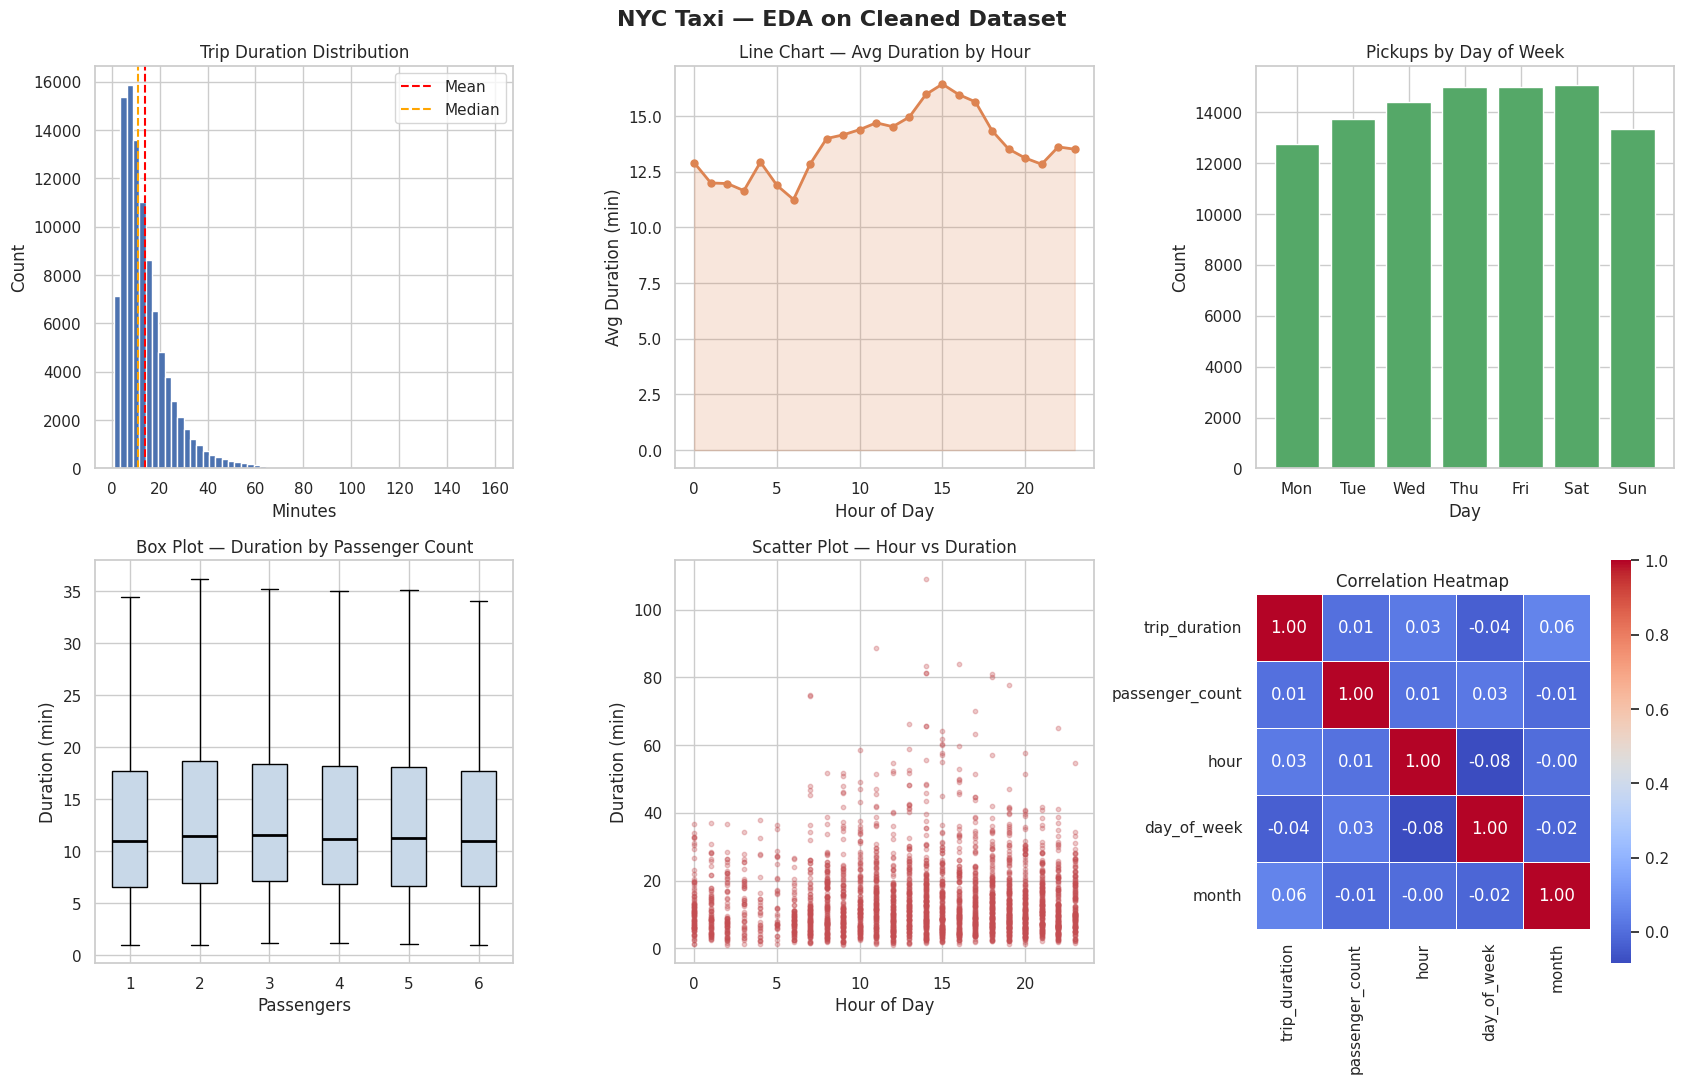

EDA visualization saved: eda_cleaned.png


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(17, 11))
fig.suptitle('NYC Taxi — EDA on Cleaned Dataset', fontsize=16, fontweight='bold')

# ── (a) Histogram — trip duration distribution ────────────────────────────────
axes[0, 0].hist(df['trip_duration'] / 60, bins=60, color='#4C72B0', edgecolor='white')
axes[0, 0].set_title('Trip Duration Distribution')
axes[0, 0].set_xlabel('Minutes')
axes[0, 0].set_ylabel('Count')
axes[0, 0].axvline(df['trip_duration'].mean()/60, color='red',  linestyle='--', label='Mean')
axes[0, 0].axvline(df['trip_duration'].median()/60, color='orange', linestyle='--', label='Median')
axes[0, 0].legend()

# ── (b) LINE CHART — average trip duration by hour of day ─────────────────────
avg_by_hour = df.groupby('hour')['trip_duration'].mean() / 60
axes[0, 1].plot(avg_by_hour.index, avg_by_hour.values,
                marker='o', linewidth=2, color='#DD8452', markersize=5)
axes[0, 1].fill_between(avg_by_hour.index, avg_by_hour.values, alpha=0.2, color='#DD8452')
axes[0, 1].set_title('Line Chart — Avg Duration by Hour')
axes[0, 1].set_xlabel('Hour of Day')
axes[0, 1].set_ylabel('Avg Duration (min)')

# ── (c) Pickups by Day of Week ────────────────────────────────────────────────
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
day_counts = df['day_of_week'].value_counts().sort_index()
axes[0, 2].bar(day_labels[:len(day_counts)], day_counts.values, color='#55A868')
axes[0, 2].set_title('Pickups by Day of Week')
axes[0, 2].set_xlabel('Day')
axes[0, 2].set_ylabel('Count')

# ── (d) BOX PLOT — trip duration by passenger count ──────────────────────────
valid_pax = sorted([p for p in df['passenger_count'].unique() if p > 0])
bp_data   = [df[df['passenger_count'] == p]['trip_duration'].values / 60 for p in valid_pax]
bp = axes[1, 0].boxplot(bp_data, labels=[str(int(p)) for p in valid_pax],
                         patch_artist=True, showfliers=False,
                         medianprops=dict(color='black', linewidth=2))
for patch in bp['boxes']:
    patch.set_facecolor('#C8D8E8')
axes[1, 0].set_title('Box Plot — Duration by Passenger Count')
axes[1, 0].set_xlabel('Passengers')
axes[1, 0].set_ylabel('Duration (min)')

# ── (e) SCATTER PLOT — hour vs trip duration ──────────────────────────────────
sc_sample = df.sample(3000, random_state=42)
axes[1, 1].scatter(sc_sample['hour'], sc_sample['trip_duration'] / 60,
                   alpha=0.3, s=10, color='#C44E52')
axes[1, 1].set_title('Scatter Plot — Hour vs Duration')
axes[1, 1].set_xlabel('Hour of Day')
axes[1, 1].set_ylabel('Duration (min)')

# ── (f) Correlation Heatmap ───────────────────────────────────────────────────
heatmap_cols = ['trip_duration', 'passenger_count', 'hour', 'day_of_week', 'month']
corr = df[heatmap_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[1, 2], linewidths=0.5, square=True)
axes[1, 2].set_title('Correlation Heatmap')

plt.tight_layout()
plt.savefig('eda_cleaned.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA visualization saved: eda_cleaned.png')

In [10]:
df.to_csv('cleaned_taxi.csv', index=False)
print(f'Cleaned dataset saved.  Shape: {df.shape}')

Cleaned dataset saved.  Shape: (99256, 14)


## ─────────────────────────────────────────
## PHASE 2 — Encoding
## ─────────────────────────────────────────

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

df = pd.read_csv('cleaned_taxi.csv')
print('Loaded cleaned data:', df.shape)

Loaded cleaned data: (99256, 14)


### Step 7 — Create Target Variable & Binning

In [12]:
# Classification target: bin trip_duration into 3 categories
df['duration_category'] = pd.cut(
    df['trip_duration'],
    bins=[0, 600, 1800, 10800],
    labels=['short', 'medium', 'long']
)

# Categorical feature: bin hour into time-of-day
df['time_of_day'] = pd.cut(
    df['hour'],
    bins=[-1, 6, 12, 18, 24],
    labels=['night', 'morning', 'afternoon', 'evening']
)

print('Class distribution:')
print(df['duration_category'].value_counts())

Class distribution:
duration_category
medium    47262
short     44292
long       7702
Name: count, dtype: int64


### Step 7a — Label Encoding (target column only — classification dataset)

In [13]:
# Label encoding applied ONLY to the target/label column
le = LabelEncoder()
df['duration_label'] = le.fit_transform(df['duration_category'].astype(str))

mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print('Label Encoding Mapping:', mapping)
# → long=0, medium=1, short=2
print(df[['duration_category', 'duration_label']].value_counts().sort_index())

Label Encoding Mapping: {'long': np.int64(0), 'medium': np.int64(1), 'short': np.int64(2)}
duration_category  duration_label
short              2                 44292
medium             1                 47262
long               0                  7702
Name: count, dtype: int64


### Step 7b — One-Hot Encoding (categorical feature columns only)

In [14]:
# One-hot encoding applied ONLY to categorical feature columns (NOT the target)
df['vendor_id'] = df['vendor_id'].astype(str)
ohe_cols = ['vendor_id', 'store_and_fwd_flag', 'time_of_day']

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
ohe_result        = ohe.fit_transform(df[ohe_cols].astype(str))
ohe_feature_names = ohe.get_feature_names_out(ohe_cols)
ohe_df            = pd.DataFrame(ohe_result, columns=ohe_feature_names, index=df.index)

print('One-Hot encoded columns:', list(ohe_feature_names))
ohe_df.head()

One-Hot encoded columns: ['vendor_id_2', 'store_and_fwd_flag_Y', 'time_of_day_evening', 'time_of_day_morning', 'time_of_day_night']


,vendor_id_2,store_and_fwd_flag_Y,time_of_day_evening,time_of_day_morning,time_of_day_night
0,1.0,0.0,1.0,0.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,1.0,0.0


In [15]:
# Combine numeric + encoded columns into final DataFrame
num_cols = ['passenger_count', 'hour', 'day_of_week', 'month', 'trip_duration', 'duration_label']
num_cols = [c for c in num_cols if c in df.columns]

df_encoded = pd.concat([df[num_cols].reset_index(drop=True),
                         ohe_df.reset_index(drop=True)], axis=1)

print('Final encoded shape:', df_encoded.shape)
df_encoded.head()

Final encoded shape: (99256, 11)


,passenger_count,hour,day_of_week,month,trip_duration,duration_label,vendor_id_2,store_and_fwd_flag_Y,time_of_day_evening,time_of_day_morning,time_of_day_night
0,1.0,20,5,1,1960.0,0,1.0,0.0,1.0,0.0,0.0
1,1.0,10,6,3,2832.0,0,1.0,0.0,0.0,1.0,0.0
2,1.0,14,3,4,961.0,1,1.0,0.0,0.0,0.0,0.0
3,4.0,13,0,1,524.0,2,1.0,0.0,0.0,0.0,0.0
4,1.0,9,2,6,495.0,2,0.0,0.0,0.0,1.0,0.0


### Step 7c — Encoding Visualizations

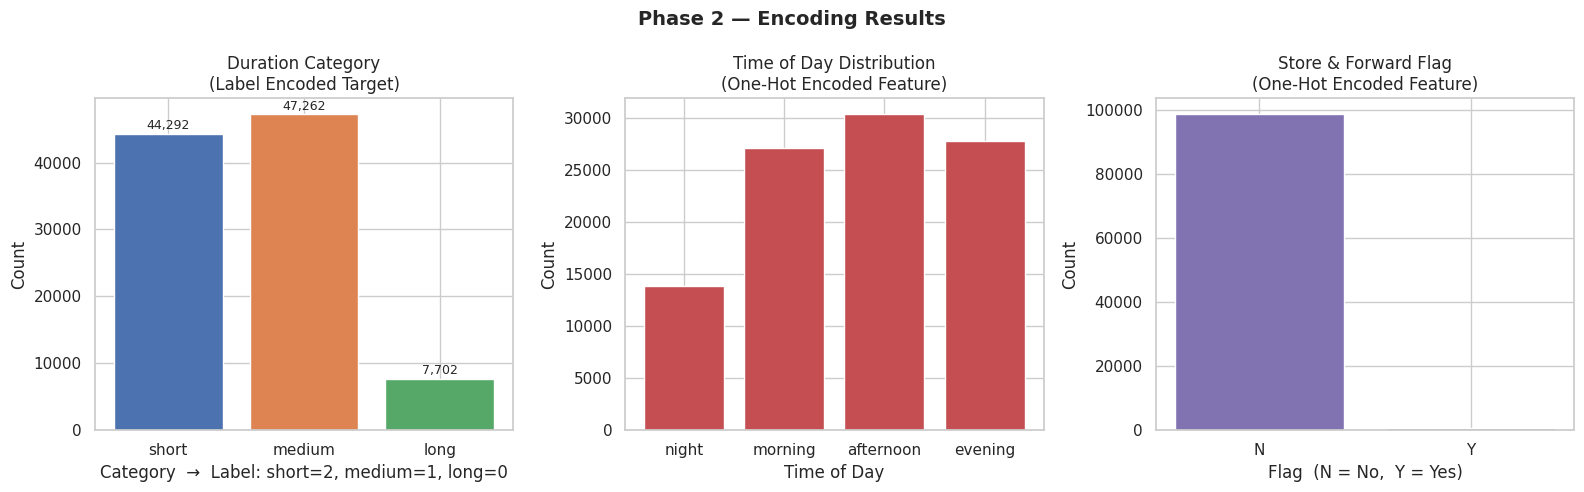

Encoding visualizations saved: encoding_visualizations.png


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Phase 2 — Encoding Results', fontsize=14, fontweight='bold')

# ── Plot 1: Duration Category counts (Label Encoded target) ──────────────────
cat_order  = ['short', 'medium', 'long']
cat_counts = df['duration_category'].value_counts().reindex(cat_order)
bars = axes[0].bar(cat_order, cat_counts.values,
                   color=['#4C72B0', '#DD8452', '#55A868'], edgecolor='white')
for bar, val in zip(bars, cat_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', va='bottom', fontsize=9)
axes[0].set_title('Duration Category\n(Label Encoded Target)')
axes[0].set_xlabel('Category  →  Label: short=2, medium=1, long=0')
axes[0].set_ylabel('Count')

# ── Plot 2: Time of Day counts (One-Hot Encoded feature) ─────────────────────
tod_order  = ['night', 'morning', 'afternoon', 'evening']
tod_counts = df['time_of_day'].value_counts().reindex(tod_order)
axes[1].bar(tod_order, tod_counts.values, color='#C44E52', edgecolor='white')
axes[1].set_title('Time of Day Distribution\n(One-Hot Encoded Feature)')
axes[1].set_xlabel('Time of Day')
axes[1].set_ylabel('Count')

# ── Plot 3: Store & Forward Flag counts (One-Hot Encoded feature) ─────────────
sff_counts = df['store_and_fwd_flag'].value_counts()
axes[2].bar(sff_counts.index, sff_counts.values, color='#8172B2', edgecolor='white')
axes[2].set_title('Store & Forward Flag\n(One-Hot Encoded Feature)')
axes[2].set_xlabel('Flag  (N = No,  Y = Yes)')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('encoding_visualizations.png', dpi=150, bbox_inches='tight')
plt.show()
print('Encoding visualizations saved: encoding_visualizations.png')

In [18]:
df_encoded.to_csv('encoded_taxi.csv', index=False)
print('Saved: encoded_taxi.csv')

Saved: encoded_taxi.csv


## ─────────────────────────────────────────
## PHASE 3 — PCA (Dimensionality Reduction)
## ─────────────────────────────────────────

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv('encoded_taxi.csv')

target_col   = 'trip_duration'
label_col    = 'duration_label'
feature_cols = [c for c in df.columns if c not in [target_col, label_col]]

# Convert every column to numeric first — pd.cut() leaves Categorical dtype
# which rejects fillna(0). astype(float) resolves it cleanly.
X = df[feature_cols].apply(lambda col: pd.to_numeric(col, errors='coerce')).fillna(0)

print(f'Features used for PCA ({len(feature_cols)}): {feature_cols}')

Features used for PCA (9): ['passenger_count', 'hour', 'day_of_week', 'month', 'vendor_id_2', 'store_and_fwd_flag_Y', 'time_of_day_evening', 'time_of_day_morning', 'time_of_day_night']


In [20]:
# Standardize — required before PCA
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f'After scaling — Mean ≈ {X_scaled.mean():.4f}, Std ≈ {X_scaled.std():.4f}')

After scaling — Mean ≈ -0.0000, Std ≈ 1.0000


In [21]:
# Full PCA to find how many components reach 95% variance
pca_full            = PCA()
pca_full.fit(X_scaled)
explained_variance  = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
n_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f'Components needed for 95% variance: {n_95}')

Components needed for 95% variance: 8


In [22]:
# Apply PCA
n_components = min(n_95, len(feature_cols))
pca          = PCA(n_components=n_components)
X_pca        = pca.fit_transform(X_scaled)
print(f'PCA shape: {X_pca.shape}  |  Variance retained: {pca.explained_variance_ratio_.sum()*100:.2f}%')

pca_cols = [f'PC{i+1}' for i in range(n_components)]
df_pca   = pd.DataFrame(X_pca, columns=pca_cols)
df_pca[target_col] = df[target_col].values
df_pca[label_col]  = df[label_col].values
df_pca.head()

PCA shape: (99256, 8)  |  Variance retained: 99.57%


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,trip_duration,duration_label
0,1.790635,-0.952257,0.174116,-1.557942,-0.433084,0.492843,1.067466,0.575556,1960.0,0
1,-1.116949,0.796697,0.662613,-0.691587,-0.178152,1.703081,1.079516,0.359488,2832.0,0
2,0.054508,-0.072306,0.306485,0.319853,-0.091487,-0.045825,0.997030,-0.946144,961.0,1
3,0.124800,0.032683,1.891012,-1.139848,0.213057,-1.840527,-0.675981,-0.881868,524.0,2
4,-1.065563,1.898160,-0.679103,1.369289,-0.013255,0.389893,-0.464946,0.381887,495.0,2


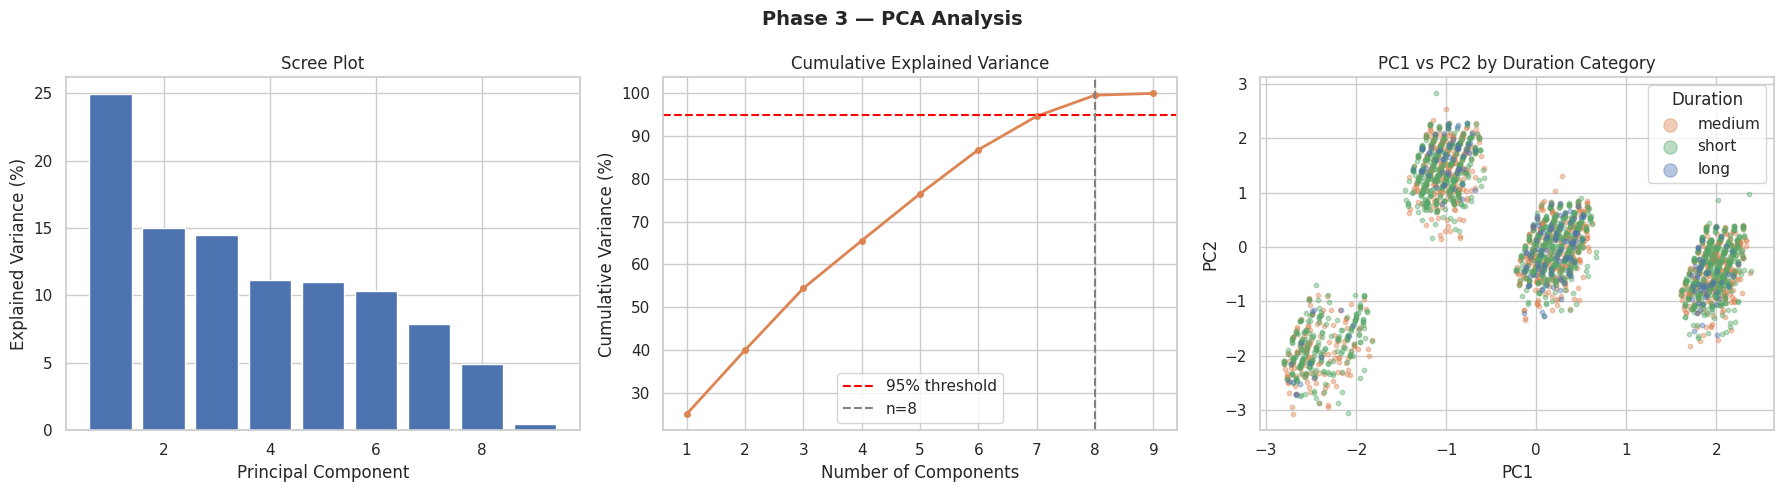

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Phase 3 — PCA Analysis', fontsize=14, fontweight='bold')

# Scree plot
axes[0].bar(range(1, len(explained_variance)+1),
            explained_variance * 100, color='#4C72B0', edgecolor='white')
axes[0].set_title('Scree Plot')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')

# Cumulative variance
axes[1].plot(range(1, len(cumulative_variance)+1), cumulative_variance * 100,
             marker='o', markersize=4, color='#DD8452', linewidth=2)
axes[1].axhline(y=95, color='red', linestyle='--', label='95% threshold')
axes[1].axvline(x=n_95, color='gray', linestyle='--', label=f'n={n_95}')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].legend()

# 2D scatter PC1 vs PC2
colors = {0: '#4C72B0', 1: '#DD8452', 2: '#55A868'}
names  = {0: 'long', 1: 'medium', 2: 'short'}
samp   = df_pca.sample(min(3000, len(df_pca)), random_state=42)
for lbl in samp[label_col].unique():
    m = samp[label_col] == lbl
    axes[2].scatter(samp.loc[m, 'PC1'], samp.loc[m, 'PC2'],
                    alpha=0.4, s=10, color=colors.get(int(lbl), 'gray'),
                    label=names.get(int(lbl), str(lbl)))
axes[2].set_title('PC1 vs PC2 by Duration Category')
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')
axes[2].legend(title='Duration', markerscale=3)

plt.tight_layout()
plt.savefig('pca_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
df_pca.to_csv('pca_taxi.csv', index=False)
print('Saved: pca_taxi.csv')

Saved: pca_taxi.csv


## ─────────────────────────────────────────
## PHASE 4 — Model Training (Logistic Regression)
## PHASE 5 — Evaluation (Accuracy, Precision, Recall, F1, Confusion Matrix)
## PHASE 6 — Benchmark Comparison (Random Forest vs Logistic Regression)
## ─────────────────────────────────────────

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

df = pd.read_csv('pca_taxi.csv')
print('Loaded PCA data:', df.shape)

Loaded PCA data: (99256, 10)


### Step 8 — Logistic Regression (Classification Model)

In [26]:
# Train / Test Split — stratified to preserve class ratios
pc_cols = [c for c in df.columns if c.startswith('PC')]
X       = df[pc_cols]
y       = df['duration_label'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {len(X_train):,}   Test: {len(X_test):,}')

Train: 79,404   Test: 19,852


In [27]:
# Train Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print('Logistic Regression training complete.')

Logistic Regression training complete.


### Step 9 — Evaluate Logistic Regression (Accuracy, Precision, Recall, F1)

In [28]:
acc_lr  = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr, average='weighted', zero_division=0)
rec_lr  = recall_score(y_test,    y_pred_lr, average='weighted', zero_division=0)
f1_lr   = f1_score(y_test,        y_pred_lr, average='weighted', zero_division=0)

print('=== LOGISTIC REGRESSION — Evaluation Metrics ===')
print(f'  Accuracy  : {acc_lr*100:.2f}%')
print(f'  Precision : {prec_lr:.4f}')
print(f'  Recall    : {rec_lr:.4f}')
print(f'  F1 Score  : {f1_lr:.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred_lr, target_names=['long', 'medium', 'short']))

=== LOGISTIC REGRESSION — Evaluation Metrics ===
  Accuracy  : 48.54%
  Precision : 0.4531
  Recall    : 0.4854
  F1 Score  : 0.4250

Classification Report:
              precision    recall  f1-score   support

        long       0.00      0.00      0.00      1540
      medium       0.48      0.81      0.60      9453
       short       0.50      0.22      0.31      8859

    accuracy                           0.49     19852
   macro avg       0.33      0.34      0.30     19852
weighted avg       0.45      0.49      0.43     19852



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Step 10 — Confusion Matrix (Logistic Regression)

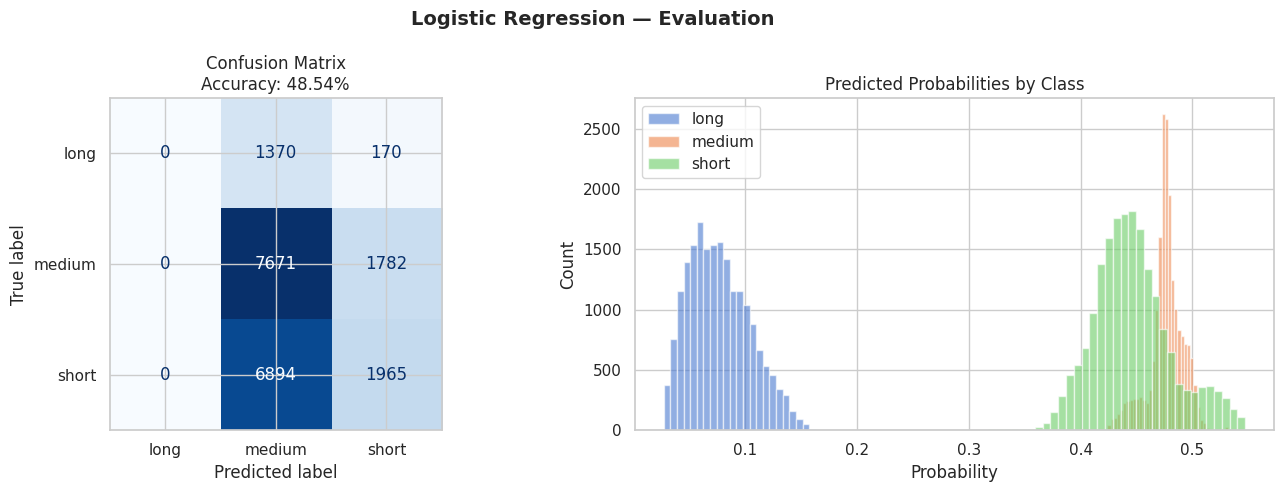

In [29]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Logistic Regression — Evaluation', fontsize=14, fontweight='bold')

# Confusion matrix
ConfusionMatrixDisplay(confusion_matrix=cm_lr,
                       display_labels=['long', 'medium', 'short']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix\nAccuracy: {acc_lr*100:.2f}%')

# Predicted probability distributions
y_prob_lr = lr.predict_proba(X_test)
for i, name in enumerate(['long', 'medium', 'short']):
    axes[1].hist(y_prob_lr[:, i], bins=40, alpha=0.6, label=name)
axes[1].set_title('Predicted Probabilities by Class')
axes[1].set_xlabel('Probability')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('lr_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 11 — Benchmark: Random Forest vs Logistic Regression

In [30]:
# Train Random Forest benchmark on the same train/test split
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print('Random Forest training complete.')

Random Forest training complete.


In [31]:
acc_rf  = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, average='weighted', zero_division=0)
rec_rf  = recall_score(y_test,    y_pred_rf, average='weighted', zero_division=0)
f1_rf   = f1_score(y_test,        y_pred_rf, average='weighted', zero_division=0)

print('=== RANDOM FOREST — Evaluation Metrics ===')
print(f'  Accuracy  : {acc_rf*100:.2f}%')
print(f'  Precision : {prec_rf:.4f}')
print(f'  Recall    : {rec_rf:.4f}')
print(f'  F1 Score  : {f1_rf:.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred_rf, target_names=['long', 'medium', 'short']))

=== RANDOM FOREST — Evaluation Metrics ===
  Accuracy  : 50.62%
  Precision : 0.4713
  Recall    : 0.5062
  F1 Score  : 0.4711

Classification Report:
              precision    recall  f1-score   support

        long       0.00      0.00      0.00      1540
      medium       0.50      0.73      0.59      9453
       short       0.52      0.36      0.42      8859

    accuracy                           0.51     19852
   macro avg       0.34      0.36      0.34     19852
weighted avg       0.47      0.51      0.47     19852



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [32]:
# ── Per-class TP / FP / FN / TN from both confusion matrices ─────────────────
cm_rf = confusion_matrix(y_test, y_pred_rf)

def extract_stats(cm, class_idx):
    tp = cm[class_idx, class_idx]
    fp = cm[:, class_idx].sum() - tp
    fn = cm[class_idx, :].sum() - tp
    tn = cm.sum() - tp - fp - fn
    return int(tp), int(fp), int(fn), int(tn)

class_names = ['long', 'medium', 'short']
print(f'\n{"Class":<10} {"Model":<22} {"TP":>7} {"FP":>7} {"FN":>7} {"TN":>7}')
print('─' * 60)
for i, cls in enumerate(class_names):
    tp_lr, fp_lr, fn_lr, tn_lr = extract_stats(cm_lr, i)
    tp_rf, fp_rf, fn_rf, tn_rf = extract_stats(cm_rf, i)
    print(f'{cls:<10} {"Logistic Regression":<22} {tp_lr:>7,} {fp_lr:>7,} {fn_lr:>7,} {tn_lr:>7,}')
    print(f'{"":<10} {"Random Forest":<22} {tp_rf:>7,} {fp_rf:>7,} {fn_rf:>7,} {tn_rf:>7,}')
    print()


Class      Model                       TP      FP      FN      TN
────────────────────────────────────────────────────────────
long       Logistic Regression          0       0   1,540  18,312
           Random Forest                0       0   1,540  18,312

medium     Logistic Regression      7,671   8,264   1,782   2,135
           Random Forest            6,898   6,947   2,555   3,452

short      Logistic Regression      1,965   1,952   6,894   9,041
           Random Forest            3,151   2,856   5,708   8,137



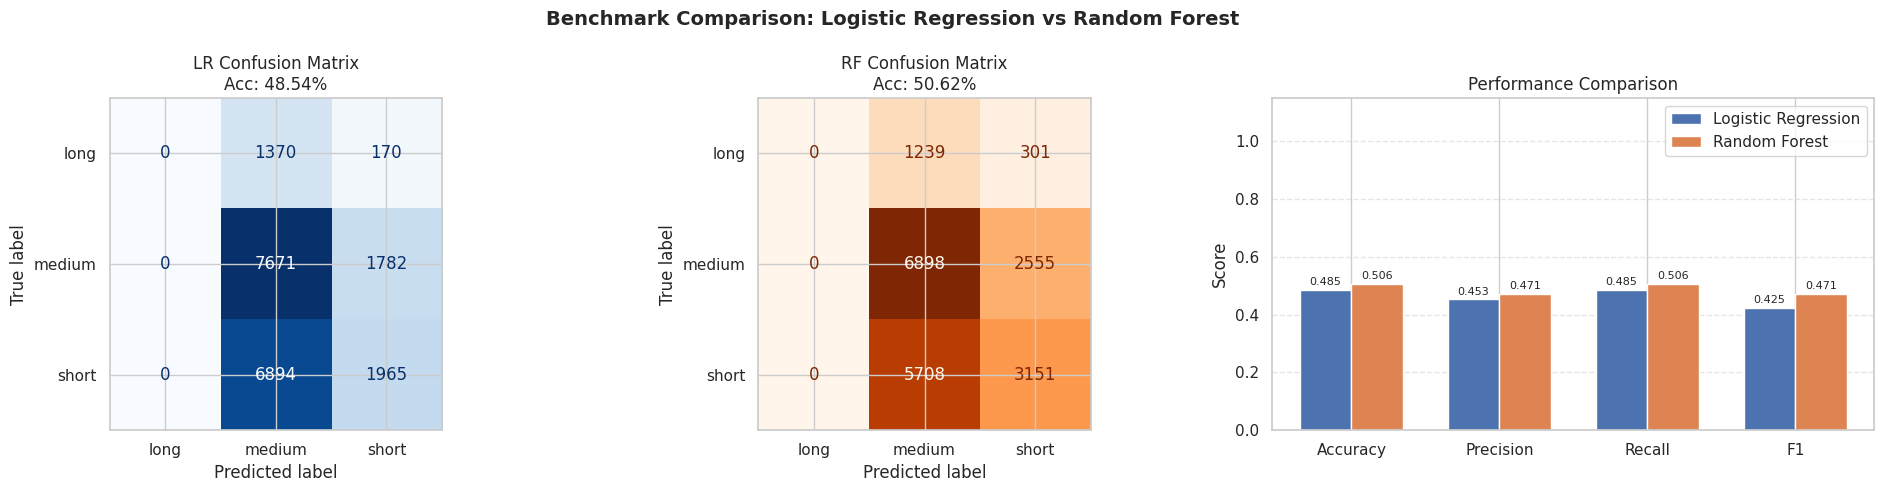

Saved: benchmark_comparison.png


In [33]:
# ── Side-by-side confusion matrices and metric comparison chart ───────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Benchmark Comparison: Logistic Regression vs Random Forest', fontsize=14, fontweight='bold')

ConfusionMatrixDisplay(confusion_matrix=cm_lr,
                       display_labels=['long', 'medium', 'short']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'LR Confusion Matrix\nAcc: {acc_lr*100:.2f}%')

ConfusionMatrixDisplay(confusion_matrix=cm_rf,
                       display_labels=['long', 'medium', 'short']).plot(
    ax=axes[1], colorbar=False, cmap='Oranges')
axes[1].set_title(f'RF Confusion Matrix\nAcc: {acc_rf*100:.2f}%')

# Bar chart comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
lr_vals = [acc_lr, prec_lr, rec_lr, f1_lr]
rf_vals = [acc_rf, prec_rf, rec_rf, f1_rf]
x = np.arange(len(metrics))
w = 0.35
b1 = axes[2].bar(x - w/2, lr_vals, w, label='Logistic Regression', color='#4C72B0')
b2 = axes[2].bar(x + w/2, rf_vals, w, label='Random Forest',       color='#DD8452')
for bar in list(b1) + list(b2):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
axes[2].set_title('Performance Comparison')
axes[2].set_xticks(x)
axes[2].set_xticklabels(metrics)
axes[2].set_ylim(0, 1.15)
axes[2].set_ylabel('Score')
axes[2].legend()
axes[2].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('benchmark_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: benchmark_comparison.png')

In [34]:
# Save models for frontend
import joblib
joblib.dump(lr,     'logistic_model.pkl')
joblib.dump(rf,     'rf_model.pkl')
joblib.dump(scaler, 'scaler.pkl')          # from Phase 3 scope
joblib.dump(pca,    'pca_model.pkl')       # from Phase 3 scope
print('Models saved: logistic_model.pkl, rf_model.pkl, scaler.pkl, pca_model.pkl')

Models saved: logistic_model.pkl, rf_model.pkl, scaler.pkl, pca_model.pkl


## ─────────────────────────────────────────
## PHASE 7 — Frontend UI (Gradio)
## ─────────────────────────────────────────

In [ ]:
# Install Gradio (run once)
# !pip install gradio --quiet

In [ ]:
import gradio as gr
import joblib
import numpy as np

# Load saved artefacts
lr_model = joblib.load('logistic_model.pkl')
rf_model = joblib.load('rf_model.pkl')
scaler   = joblib.load('scaler.pkl')
pca_mdl  = joblib.load('pca_model.pkl')

label_map = {0: '🕐 Long  (30+ minutes)', 1: '🕒 Medium (10-30 minutes)', 2: '🏎  Short  (0-10 minutes)'}

def predict_trip(passenger_count, hour, day_of_week_str, month,
                 vendor_str, sff_str, tod_str, model_choice):
    dow_map = {'Monday':0,'Tuesday':1,'Wednesday':2,'Thursday':3,'Friday':4,'Saturday':5,'Sunday':6}
    tod_map = {'Night (12am-6am)':'night','Morning (6am-12pm)':'morning',
               'Afternoon (12pm-6pm)':'afternoon','Evening (6pm-12am)':'evening'}

    # Reconstruct OHE features (must match training columns exactly)
    vendor_2      = 1 if vendor_str == 'Vendor 2' else 0
    sff_Y         = 1 if sff_str == 'Yes' else 0
    tod           = tod_map[tod_str]
    tod_evening   = 1 if tod == 'evening'   else 0
    tod_morning   = 1 if tod == 'morning'   else 0
    tod_night     = 1 if tod == 'night'     else 0

    dow = dow_map[day_of_week_str]

    # Feature order: passenger_count, hour, day_of_week, month,
    #                vendor_id_2, store_and_fwd_flag_Y,
    #                time_of_day_evening, time_of_day_morning, time_of_day_night
    X_raw = np.array([[passenger_count, hour, dow, month,
                        vendor_2, sff_Y, tod_evening, tod_morning, tod_night]])

    X_scaled = scaler.transform(X_raw)
    X_pca    = pca_mdl.transform(X_scaled)

    model = lr_model if model_choice == 'Logistic Regression' else rf_model
    pred  = model.predict(X_pca)[0]
    proba = model.predict_proba(X_pca)[0]

    label    = label_map[pred]
    prob_str = (f"Long:   {proba[0]*100:.1f}%\n"
                f"Medium: {proba[1]*100:.1f}%\n"
                f"Short:  {proba[2]*100:.1f}%")
    return label, prob_str


with gr.Blocks(title='NYC Taxi Duration Predictor') as demo:
    gr.Markdown('#  NYC Taxi Trip Duration Predictor')
    gr.Markdown('Fill in the trip details and click **Predict** to classify the trip duration.')

    with gr.Row():
        with gr.Column():
            passenger_count = gr.Slider(1, 6, value=1, step=1,   label='Passenger Count')
            hour            = gr.Slider(0, 23, value=8, step=1,  label='Pickup Hour (0–23)')
            day_of_week     = gr.Dropdown(
                ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'],
                value='Monday', label='Day of Week')
            month           = gr.Slider(1, 12, value=6, step=1,  label='Month')

        with gr.Column():
            vendor_id          = gr.Radio(['Vendor 1','Vendor 2'], value='Vendor 1', label='Vendor')
            store_and_fwd_flag = gr.Radio(['No','Yes'],            value='No',       label='Store & Forward Flag')
            time_of_day        = gr.Dropdown(
                ['Night (12am-6am)','Morning (6am-12pm)',
                 'Afternoon (12pm-6pm)','Evening (6pm-12am)'],
                value='Morning (6am-12pm)', label='Time of Day')
            model_choice       = gr.Radio(
                ['Logistic Regression','Random Forest'],
                value='Logistic Regression', label='Model to Use')

    predict_btn = gr.Button('Predict Duration', variant='primary')

    with gr.Row():
        out_label = gr.Textbox(label='Predicted Duration Category')
        out_proba = gr.Textbox(label='Class Probabilities')

    predict_btn.click(
        fn=predict_trip,
        inputs=[passenger_count, hour, day_of_week, month,
                vendor_id, store_and_fwd_flag, time_of_day, model_choice],
        outputs=[out_label, out_proba]
    )

demo.launch(share=True)   # share=True generates a public link